# Short Term Memory

In [18]:
from langchain_openai import ChatOpenAI
from langgraph.graph import MessagesState, START, StateGraph
from langgraph.checkpoint.memory import InMemorySaver

from langchain_core.messages.utils import trim_messages, count_tokens_approximately

In [12]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [13]:
MAX_TOKENS = 128
def get_groq_llm():
    return ChatOpenAI(
        model="openai/gpt-oss-20b",
        base_url="https://api.groq.com/openai/v1",
        api_key=os.getenv("GROQ_API_KEY"),
        temperature=0.7, max_tokens=2000
    )

model = get_groq_llm()

Usually, you build a custom Python `TypedDict` (like an `AgentState`) to hold your variables (e.g., `messages`, `documents`, `rephrased_question`). However, for simple chatbots, you often only need to track the conversational history.

`MessagesState` is a pre-built, out-of-the-box State Schema provided by LangGraph. * Instead of forcing you to write a custom Python class to track messages, LangGraph gives you this ready-made template.

In [14]:
def chat(state: MessagesState):
    trimmed_messages = trim_messages(
        state["messages"],
        strategy="last",
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKENS,
    )

    response = model.invoke(trimmed_messages)
    return {"messages": [response]}

```
trim_messages is essentially a highly intelligent pair of scissors.

Instead of writing complex Python logic to slice your arrays (messages[-10:]), trim_messages looks at your message history, counts the actual LLM tokens, and safely cuts off the oldest messages so the array fits perfectly into the LLM's brain—without breaking the flow of the conversation.
```

## State Graph

In [19]:
builder = StateGraph(MessagesState)
builder.add_node('chat', chat)
builder.add_edge(START, 'chat')

graph = builder.compile(checkpointer=InMemorySaver())


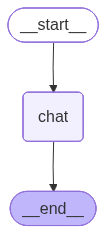

In [21]:
graph

In [20]:
config = {"configurable": {"thread_id": "trim-demo"}}

In [23]:
while True:
    user_input = input("You: ")
    if user_input.lower() in ["exit", "quit"]:
        break
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]}, config)
    print("Bot:", result["messages"][-1].content)

Bot: Hi Vignesh! 👋 How can I help you today?
Bot: Sure thing! Could you let me know which city or region you’re interested in? That way I can give you the most accurate forecast for today.
Bot: I don’t have live data access, so I can’t give you the exact current conditions for today. However, here’s what you can expect based on typical patterns for this time of year, and a quick way to get the precise numbers:

| City | Typical Weather (late June) | What to Check |
|------|-----------------------------|---------------|
| **Bengaluru** | Warm, 25–30 °C (77–86 °F), partly cloudy, light showers possible | Check a local app (e.g., AccuWeather, Weather.com) or the Indian Meteorological Department (IMD) for a 12‑hour forecast. |
| **Chennai** | Hot, 30–35 °C (86–95 °F), high humidity, thunderstorms likely in the evenings | Use the same apps or the IMD; Chennai often gets evening showers during monsoon season. |
| **Delhi** | Warm to hot, 32–38 °C (90–100 °F), low humidity, clear skies, but h